# 条件质心可视化

面向 `trishift / scouter / gears / genepert` 的 condition centroid 级别可视化。

这个 notebook 会完成以下工作：
- 对每个 condition 计算 `DE` 特征空间中的质心
- 比较每个 condition 下 `Truth / Pred / Ctrl` 的 centroid
- 输出 centroid UMAP、delta-centroid UMAP 以及对应统计结果

默认约定如下：
- `trishift/scouter` 默认推荐使用 `variant_tag="nearest"`
- `gears/genepert` 不需要设置 `variant_tag`
- `feature_mode="full"` 需要结果 `pkl` 中包含 full-gene 特征；否则请使用默认的 `deg`


In [1]:
from __future__ import annotations

import importlib
import sys
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

repo_root = Path.cwd()
if not (repo_root / "scripts").exists() and (repo_root.parent / "scripts").exists():
    repo_root = repo_root.parent

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))
if str(repo_root / "src") not in sys.path:
    sys.path.insert(0, str(repo_root / "src"))

import scripts.trishift.analysis.condition_centroid_vis as condition_centroid_vis
import scripts.trishift.analysis._notebook_vis as notebook_vis
importlib.reload(condition_centroid_vis)
importlib.reload(notebook_vis)

run_condition_centroid_visualization = condition_centroid_vis.run_condition_centroid_visualization
render_metric_barplot = notebook_vis.render_metric_barplot
render_image_panel = notebook_vis.render_image_panel

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 220)
repo_root


D:\conda_envs\biolord\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


WindowsPath('E:/CODE/trishift')

## 参数

在这里设置模型、数据集、split，以及输出目录和 UMAP 作图参数。


In [2]:
models = ["trishift",  "gears", "genepert"]
dataset = "adamson"
split_ids = [1, 2, 3, 4, 5]
result_dirs = {}  # optional: {"trishift": repo_root / "artifacts" / "results" / dataset / "state"}
variant_tags = {"trishift": "nearest", "scouter": "nearest"}
feature_mode = "deg"  # deg | full
include_ctrl = True
plot_delta = True
umap_n_neighbors = None
umap_min_dist = 0.15
save_dpi = 420
seed = 24
out_root = repo_root / "notebooks" / "artifacts" / f"condition_centroid_compare_{dataset}"
out_root.mkdir(parents=True, exist_ok=True)

selected_metrics = [
    "centroid_cosine_mean",
    "delta_cosine_mean",
    "centroid_dist_mean",
    "delta_centroid_dist_mean",
]
panel_key_main = "truth_pred_ctrl_centroid_umap"
panel_key_delta = "delta_centroid_umap"

run_specs = []
for model_name in models:
    for split_id in split_ids:
        run_specs.append({
            "model_name": model_name,
            "dataset": dataset,
            "split_id": int(split_id),
            "result_dir": result_dirs.get(model_name),
            "variant_tag": variant_tags.get(model_name, ""),
        })
run_specs[:3]


[{'model_name': 'trishift',
  'dataset': 'adamson',
  'split_id': 1,
  'result_dir': None,
  'variant_tag': 'nearest'},
 {'model_name': 'trishift',
  'dataset': 'adamson',
  'split_id': 2,
  'result_dir': None,
  'variant_tag': 'nearest'},
 {'model_name': 'trishift',
  'dataset': 'adamson',
  'split_id': 3,
  'result_dir': None,
  'variant_tag': 'nearest'}]

In [3]:
summary_frames = []
metrics_frames = []
points_frames = []
points_raw_frames = []
run_rows = []

for spec in run_specs:
    run_label = f"{spec['model_name']}_split{spec['split_id']}"
    run_out_root = out_root / run_label
    result = run_condition_centroid_visualization(
        model_name=spec["model_name"],
        dataset=spec["dataset"],
        split_id=spec["split_id"],
        result_dir=spec["result_dir"],
        out_root=run_out_root,
        variant_tag=spec["variant_tag"],
        feature_mode=feature_mode,
        include_ctrl=include_ctrl,
        plot_delta=plot_delta,
        umap_n_neighbors=umap_n_neighbors,
        umap_min_dist=umap_min_dist,
        save_dpi=save_dpi,
        seed=seed,
    )
    summary = result.summary_df.copy()
    summary["model_name"] = spec["model_name"]
    summary["dataset"] = spec["dataset"]
    summary["split_id"] = int(spec["split_id"])
    summary["run_label"] = run_label
    summary_frames.append(summary)

    metrics = result.metrics_df.copy()
    metrics["model_name"] = spec["model_name"]
    metrics["run_label"] = run_label
    metrics_frames.append(metrics)

    points = result.points_df.copy()
    points["model_name"] = spec["model_name"]
    points["run_label"] = run_label
    points_frames.append(points)

    points_raw = result.points_raw_df.copy()
    points_raw["model_name"] = spec["model_name"]
    points_raw["run_label"] = run_label
    points_raw_frames.append(points_raw)

    run_rows.append({"run_label": run_label, "out_dir": str(result.out_dir)})

summary_all_df = pd.concat(summary_frames, ignore_index=True) if summary_frames else pd.DataFrame()
metrics_all_df = pd.concat(metrics_frames, ignore_index=True) if metrics_frames else pd.DataFrame()
points_all_df = pd.concat(points_frames, ignore_index=True) if points_frames else pd.DataFrame()
points_raw_all_df = pd.concat(points_raw_frames, ignore_index=True) if points_raw_frames else pd.DataFrame()
summary_metric_cols = [
    "centroid_dist",
    "delta_centroid_dist",
    "centroid_cosine",
    "delta_cosine",
    "truth_ctrl_shift_norm",
    "pred_ctrl_shift_norm",
]
if metrics_all_df.empty:
    summary_by_model_df = pd.DataFrame()
else:
    summary_rows = []
    for model_name, sub in metrics_all_df.groupby("model_name"):
        row = {
            "model_name": str(model_name),
            "n_conditions": float(sub.groupby("split_id")["condition"].nunique().mean()),
            "n_splits": int(sub["split_id"].nunique()),
        }
        for col in summary_metric_cols:
            vals = pd.to_numeric(sub[col], errors="coerce")
            row[f"{col}_mean"] = float(vals.mean()) if vals.notna().any() else float("nan")
            row[f"{col}_median"] = float(vals.median()) if vals.notna().any() else float("nan")
            row[f"{col}_std"] = float(vals.std()) if vals.notna().sum() > 1 else float("nan")
        summary_rows.append(row)
    summary_by_model_df = pd.DataFrame(summary_rows)
runs_df = pd.DataFrame(run_rows)

def align_points_to_model_gene_space(raw_df):
    if raw_df.empty or "feature_names" not in raw_df.columns:
        return raw_df.copy()
    names = []
    for arr in raw_df["feature_names"].tolist():
        if arr is None:
            continue
        names.extend([str(x) for x in list(arr)])
    if not names:
        return raw_df.copy()
    union_genes = pd.Index(sorted(set(names))).to_numpy(dtype=object)
    aligned = raw_df.copy()
    aligned["vector"] = [
        condition_centroid_vis._align_vector_to_gene_space(vec, genes, union_genes)
        for vec, genes in zip(raw_df["vector"].tolist(), raw_df["feature_names"].tolist())
    ]
    aligned["feature_names"] = [union_genes] * len(aligned)
    return aligned

summary_all_df.to_csv(out_root / "condition_centroid_summary_all.csv", index=False, encoding="utf-8-sig")
summary_by_model_df.to_csv(out_root / "condition_centroid_summary_by_model.csv", index=False, encoding="utf-8-sig")
metrics_all_df.to_csv(out_root / "condition_centroid_metrics_all.csv", index=False, encoding="utf-8-sig")
points_all_df.to_csv(out_root / "condition_centroid_points_all.csv", index=False, encoding="utf-8-sig")
runs_df.to_csv(out_root / "condition_centroid_runs.csv", index=False, encoding="utf-8-sig")

barplot_path = render_metric_barplot(summary_by_model_df, id_col="model_name", metric_cols=selected_metrics, out_path=out_root / "condition_centroid_metric_barplot.png", title="Condition centroid summary by model")

single_main_paths = []
single_delta_paths = []
for model_name, raw_sub in points_raw_all_df.groupby("model_name") if not points_raw_all_df.empty else []:
    raw_sub_aligned = align_points_to_model_gene_space(raw_sub)
    plot_df, _ = condition_centroid_vis._fit_umap(
        raw_sub_aligned,
        seed=int(seed),
        umap_n_neighbors=umap_n_neighbors,
        umap_min_dist=float(umap_min_dist),
    )
    if include_ctrl and (plot_df["kind"].astype(str) == "Ctrl").any():
        main_path = out_root / f"{model_name}_truth_pred_ctrl_centroid_umap_all_splits.png"
        condition_centroid_vis._plot_truth_pred_ctrl(
            points_df=plot_df,
            out_path=main_path,
            title=f"{model_name}:{dataset} all splits | Truth / Pred / Ctrl centroid UMAP",
            save_dpi=int(save_dpi),
        )
    else:
        main_path = out_root / f"{model_name}_truth_pred_centroid_umap_all_splits.png"
        condition_centroid_vis._plot_truth_pred(
            points_df=plot_df,
            out_path=main_path,
            title=f"{model_name}:{dataset} all splits | Truth vs Pred centroid UMAP",
            save_dpi=int(save_dpi),
        )
    single_main_paths.append(main_path)

    if plot_delta:
        metrics_sub = metrics_all_df[metrics_all_df["model_name"].astype(str) == str(model_name)].copy()
        delta_raw = condition_centroid_vis._build_delta_points(metrics_df=metrics_sub, points_df=raw_sub_aligned)
        if not delta_raw.empty:
            delta_raw_aligned = align_points_to_model_gene_space(delta_raw)
            delta_plot_df, _ = condition_centroid_vis._fit_umap(
                delta_raw_aligned,
                seed=int(seed) + 17,
                umap_n_neighbors=umap_n_neighbors,
                umap_min_dist=float(umap_min_dist),
            )
            delta_path = out_root / f"{model_name}_delta_centroid_umap_all_splits.png"
            condition_centroid_vis._plot_delta(
                delta_plot_df=delta_plot_df,
                out_path=delta_path,
                title=f"{model_name}:{dataset} all splits | Delta centroid UMAP",
                save_dpi=int(save_dpi),
            )
            single_delta_paths.append(delta_path)

print(f"out_root: {out_root}")
display(summary_by_model_df)
display(summary_all_df.head(20))
display(metrics_all_df.head(20))


D:\conda_envs\biolord\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


D:\conda_envs\biolord\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


D:\conda_envs\biolord\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


D:\conda_envs\biolord\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


D:\conda_envs\biolord\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


...

D:\conda_envs\biolord\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


out_root: E:\CODE\trishift\notebooks\artifacts\condition_centroid_compare_adamson


,model_name,n_conditions,n_splits,centroid_dist_mean,centroid_dist_median,centroid_dist_std,delta_centroid_dist_mean,delta_centroid_dist_median,delta_centroid_dist_std,centroid_cosine_mean,centroid_cosine_median,centroid_cosine_std,delta_cosine_mean,delta_cosine_median,delta_cosine_std,truth_ctrl_shift_norm_mean,truth_ctrl_shift_norm_median,truth_ctrl_shift_norm_std,pred_ctrl_shift_norm_mean,pred_ctrl_shift_norm_median,pred_ctrl_shift_norm_std
0,gears,21.0,5,1.324995,0.962449,0.996510,1.324995,0.962449,0.996510,0.993083,0.997629,0.010432,0.825844,0.942814,0.387688,2.477678,2.104561,0.704371,1.575324,1.460574,0.457031
1,genepert,17.0,5,1.108634,0.657747,0.994464,1.108634,0.657747,0.994464,0.994061,0.998989,0.009650,0.908120,0.971882,0.201672,2.466269,2.057837,0.838773,1.657688,1.624942,0.245554
2,trishift,17.0,5,0.969842,0.662966,0.831440,0.969842,0.662966,0.831440,0.995777,0.998880,0.006725,0.882607,0.962905,0.251892,2.123408,1.881163,0.741886,1.594048,1.573788,0.290765


,n_conditions,n_splits,centroid_dist_mean,centroid_dist_median,centroid_dist_std,delta_centroid_dist_mean,delta_centroid_dist_median,delta_centroid_dist_std,centroid_cosine_mean,centroid_cosine_median,centroid_cosine_std,delta_cosine_mean,delta_cosine_median,delta_cosine_std,truth_ctrl_shift_norm_mean,truth_ctrl_shift_norm_median,truth_ctrl_shift_norm_std,pred_ctrl_shift_norm_mean,pred_ctrl_shift_norm_median,pred_ctrl_shift_norm_std,model_name,dataset,split_id,feature_mode,variant_tag,include_ctrl,plot_delta,umap_n_neighbors,umap_min_dist,embed_mode,run_label
0,17,1,0.914067,0.686243,0.664362,0.914067,0.686243,0.664361,0.996842,0.998733,0.004220,0.868137,0.943710,0.312229,1.994481,1.852951,0.642121,1.630474,1.693668,0.355833,trishift,adamson,1,deg,nearest,True,True,15,0.15,umap,trishift_split1
1,17,1,0.957763,0.662966,0.754622,0.957763,0.662966,0.754622,0.995839,0.998880,0.005779,0.862577,0.973352,0.360314,2.136128,1.896198,0.846865,1.624834,1.664650,0.198550,trishift,adamson,2,deg,nearest,True,True,15,0.15,umap,trishift_split2
2,17,1,0.937459,0.680176,0.901453,0.937459,0.680176,0.901453,0.996145,0.998639,0.007894,0.872001,0.943140,0.229408,2.069755,1.894296,0.617645,1.605960,1.610912,0.336447,trishift,adamson,3,deg,nearest,True,True,15,0.15,umap,trishift_split3
3,17,1,0.946578,0.627344,0.868405,0.946578,0.627344,0.868405,0.996075,0.999167,0.007325,0.889684,0.957425,0.167787,2.042905,1.812259,0.666579,1.545485,1.526083,0.221618,trishift,adamson,4,deg,nearest,True,True,15,0.15,umap,trishift_split4
4,17,1,1.093342,0.568990,1.015066,1.093342,0.568990,1.015066,0.993984,0.999221,0.008087,0.920636,0.967204,0.150528,2.373769,1.888202,0.916451,1.563484,1.554324,0.330817,trishift,adamson,5,deg,nearest,True,True,15,0.15,umap,trishift_split5
5,21,1,1.661852,1.099189,1.281209,1.661852,1.099189,1.281209,0.990053,0.996685,0.014815,0.640495,0.902694,0.644012,2.610165,2.094143,0.856471,1.834629,1.453819,0.825237,gears,adamson,1,deg,,True,True,15,0.15,umap,gears_split1
6,21,1,1.462239,0.895971,1.176258,1.462239,0.895971,1.176258,0.991271,0.997629,0.012201,0.824422,0.966891,0.368467,2.676636,2.290396,0.828510,1.585577,1.481178,0.399540,gears,adamson,2,deg,,True,True,15,0.15,umap,gears_split2
7,21,1,1.381178,0.950642,0.994879,1.381178,0.950642,0.994879,0.991798,0.997045,0.010747,0.826605,0.954379,0.389139,2.445480,2.197609,0.652514,1.409461,1.396352,0.122979,gears,adamson,3,deg,,True,True,15,0.15,umap,gears_split3
8,21,1,0.958045,0.762962,0.481191,0.958045,0.762962,0.481191,0.996680,0.998083,0.004123,0.922484,0.966939,0.095828,2.281071,2.078620,0.569884,1.623609,1.557842,0.297494,gears,adamson,4,deg,,True,True,15,0.15,umap,gears_split4
9,21,1,1.161659,0.934365,0.778284,1.161659,0.934365,0.778284,0.995612,0.997903,0.005469,0.915217,0.963043,0.127168,2.375038,2.111374,0.544679,1.423346,1.433273,0.124855,gears,adamson,5,deg,,True,True,15,0.15,umap,gears_split5


,split_id,condition,feature_mode_used,feature_dim,n_truth,n_pred,n_ctrl,centroid_dist,centroid_cosine,truth_ctrl_shift_norm,pred_ctrl_shift_norm,delta_centroid_dist,delta_cosine,model_name,run_label
0,1,ATP5B+ctrl,deg,19,547,300,300,0.391943,0.999583,1.714049,1.955730,0.391943,0.985799,trishift,trishift_split1
1,1,BHLHE40+ctrl,deg,19,504,300,300,2.706765,0.984724,1.012919,2.204660,2.706765,-0.322426,trishift,trishift_split1
2,1,CARS+ctrl,deg,19,429,300,300,1.888861,0.988894,3.988026,2.163916,1.888861,0.986070,trishift,trishift_split1
3,1,CCND3+ctrl,deg,19,310,300,300,1.418623,0.995287,2.453582,1.212612,1.418623,0.920597,trishift,trishift_split1
4,1,COPB1+ctrl,deg,20,185,300,300,0.646041,0.998627,1.970920,1.540325,0.646041,0.961797,trishift,trishift_split1
5,1,DERL2+ctrl,deg,19,542,300,300,0.686243,0.999050,1.544022,1.098419,0.686243,0.919702,trishift,trishift_split1
6,1,HARS+ctrl,deg,19,272,300,300,1.054132,0.996644,2.491273,1.693668,1.054132,0.943710,trishift,trishift_split1
7,1,HYOU1+ctrl,deg,19,432,300,300,0.602593,0.999133,2.219721,1.987916,0.602593,0.964943,trishift,trishift_split1
8,1,MANF+ctrl,deg,19,462,300,300,0.170121,0.999946,1.686728,1.800693,0.170121,0.997374,trishift,trishift_split1
9,1,MRPL39+ctrl,deg,19,582,300,300,0.646344,0.998733,1.728320,1.464396,0.646344,0.931230,trishift,trishift_split1


## 图像

这里展示生成的 centroid UMAP 和 delta-centroid UMAP 图。


E:\CODE\trishift\notebooks\artifacts\condition_centroid_compare_adamson\condition_centroid_metric_barplot.png


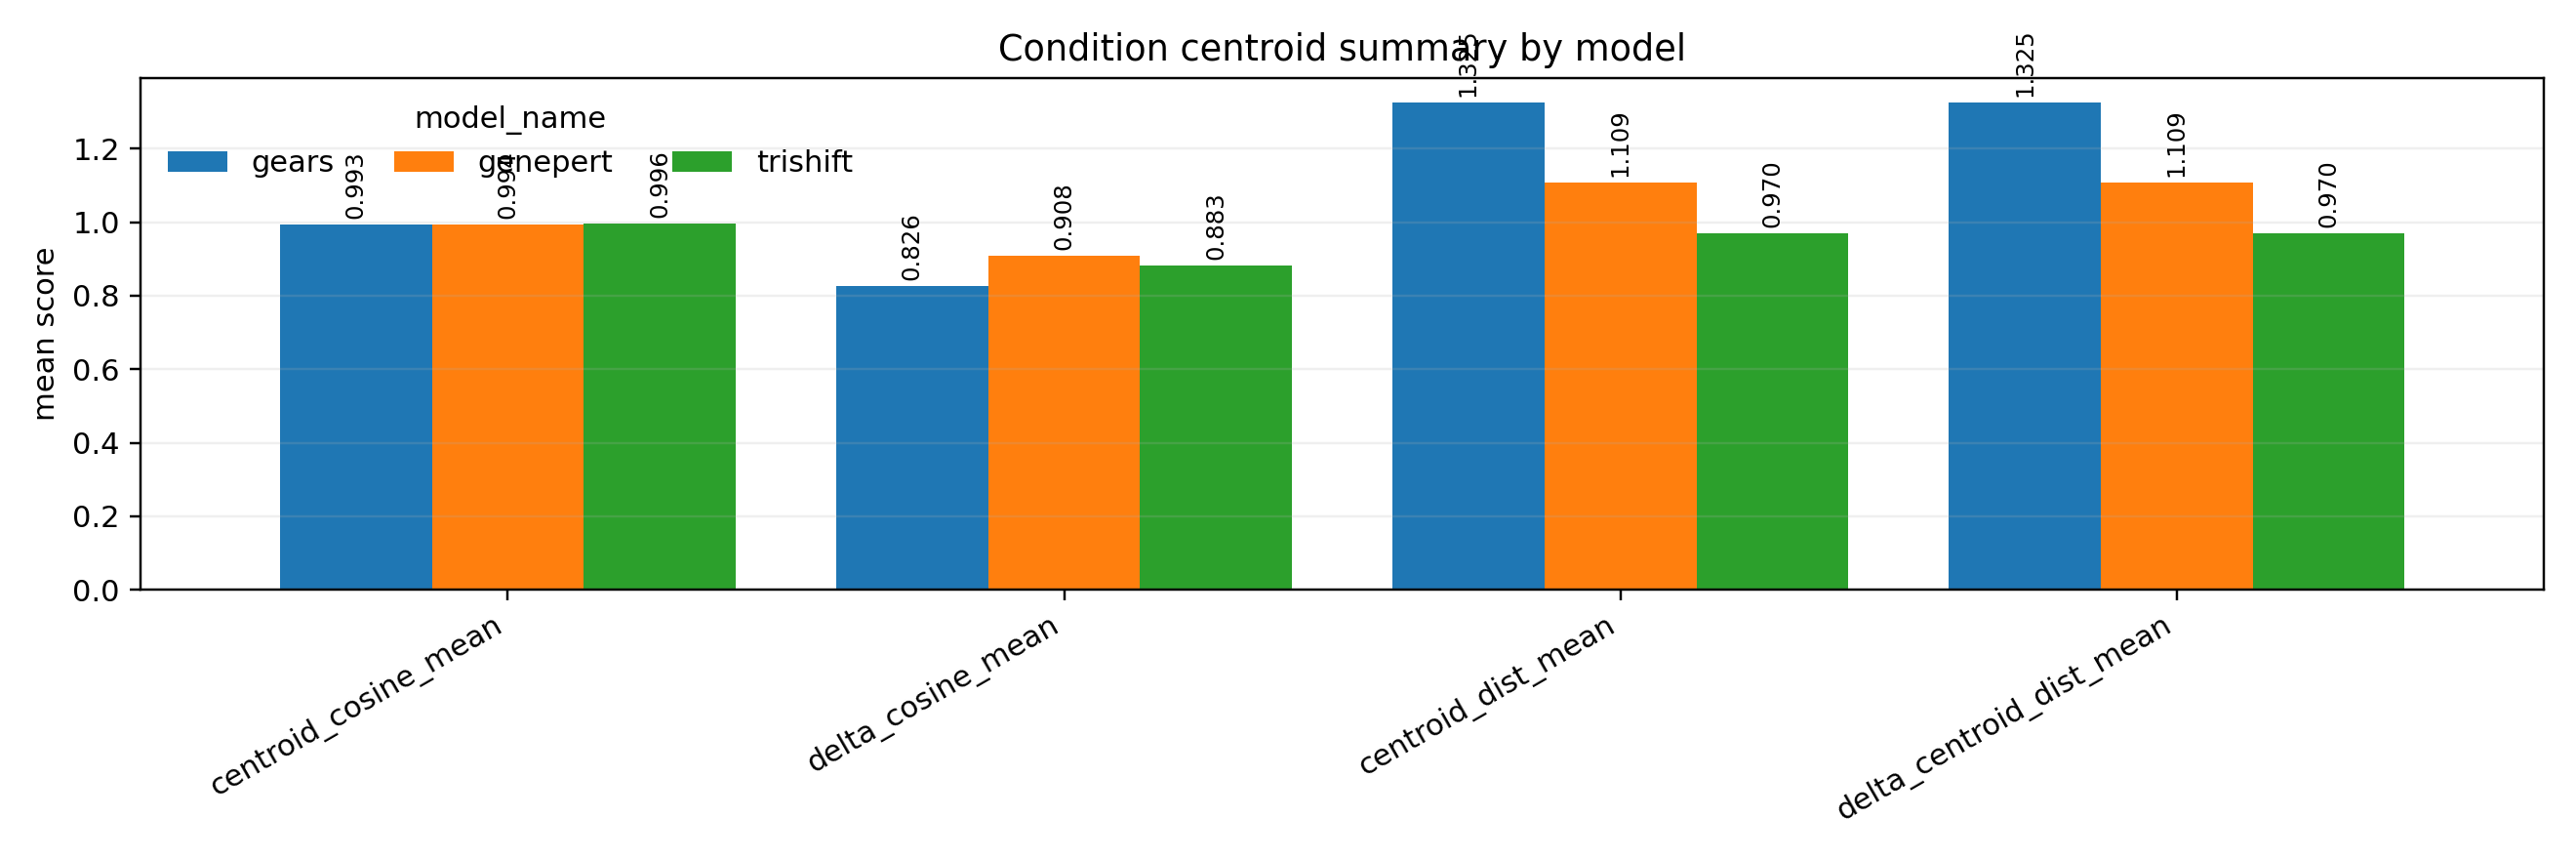

E:\CODE\trishift\notebooks\artifacts\condition_centroid_compare_adamson\gears_truth_pred_ctrl_centroid_umap_all_splits.png


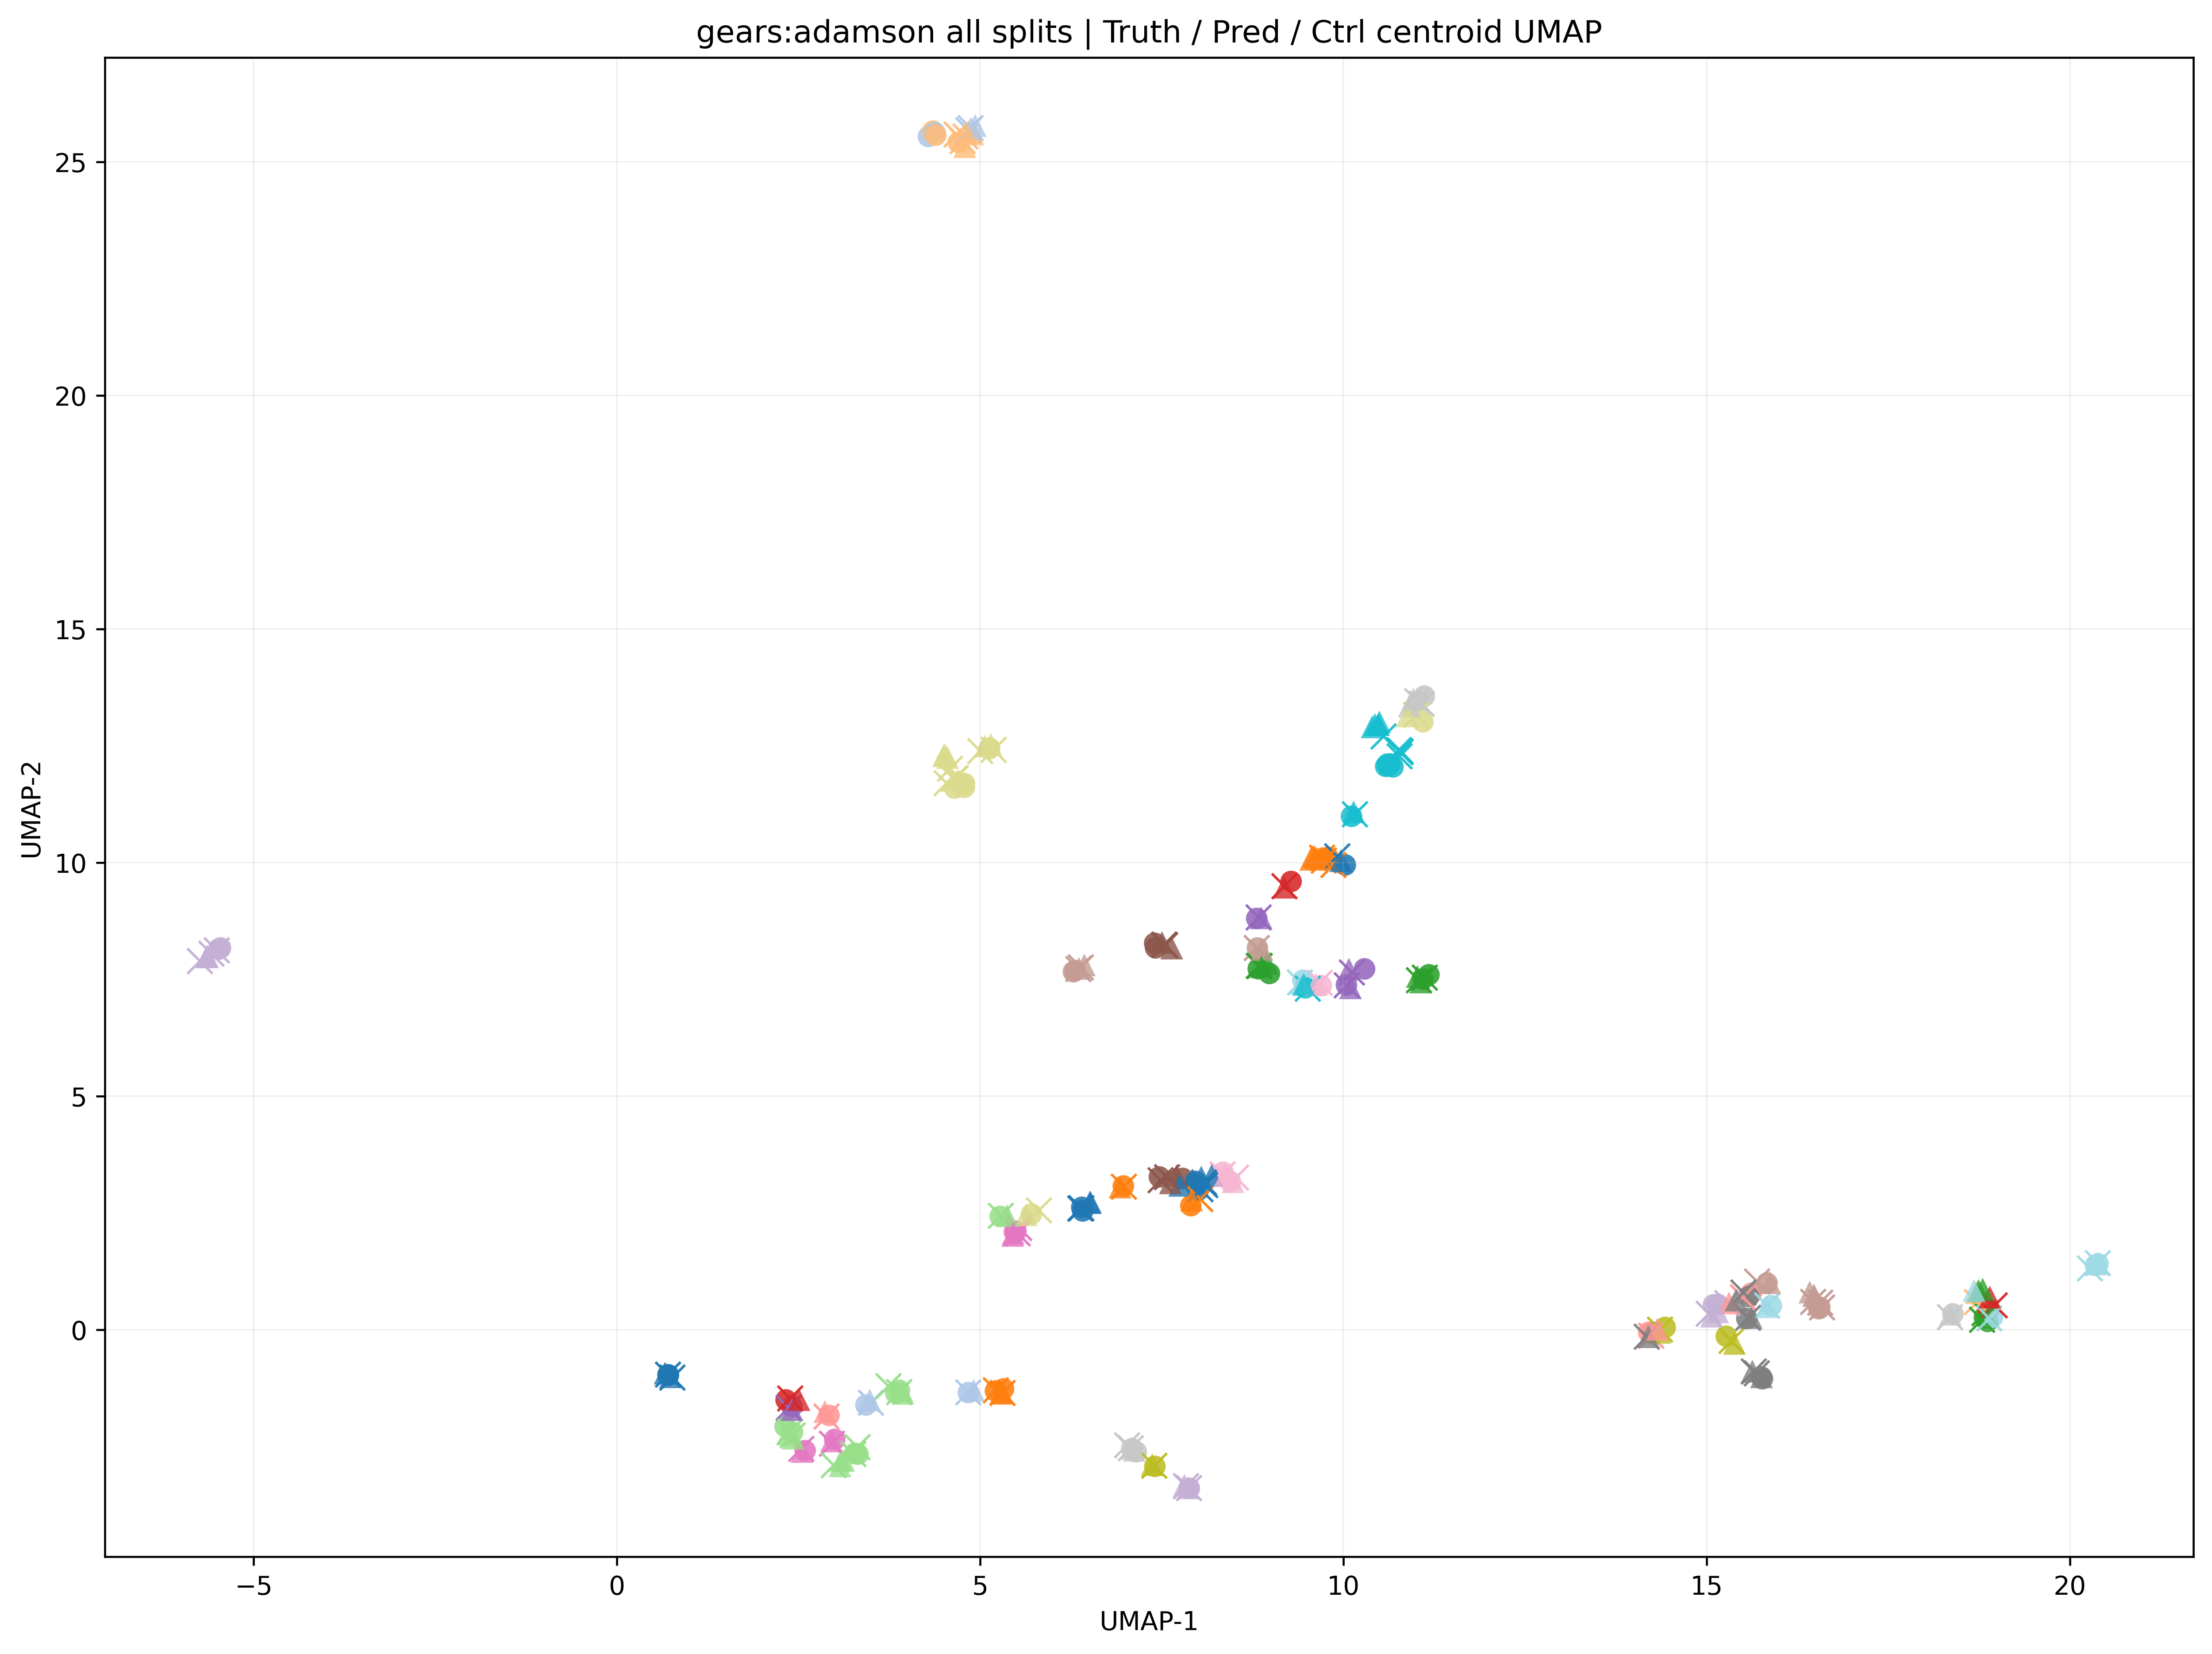

E:\CODE\trishift\notebooks\artifacts\condition_centroid_compare_adamson\genepert_truth_pred_ctrl_centroid_umap_all_splits.png


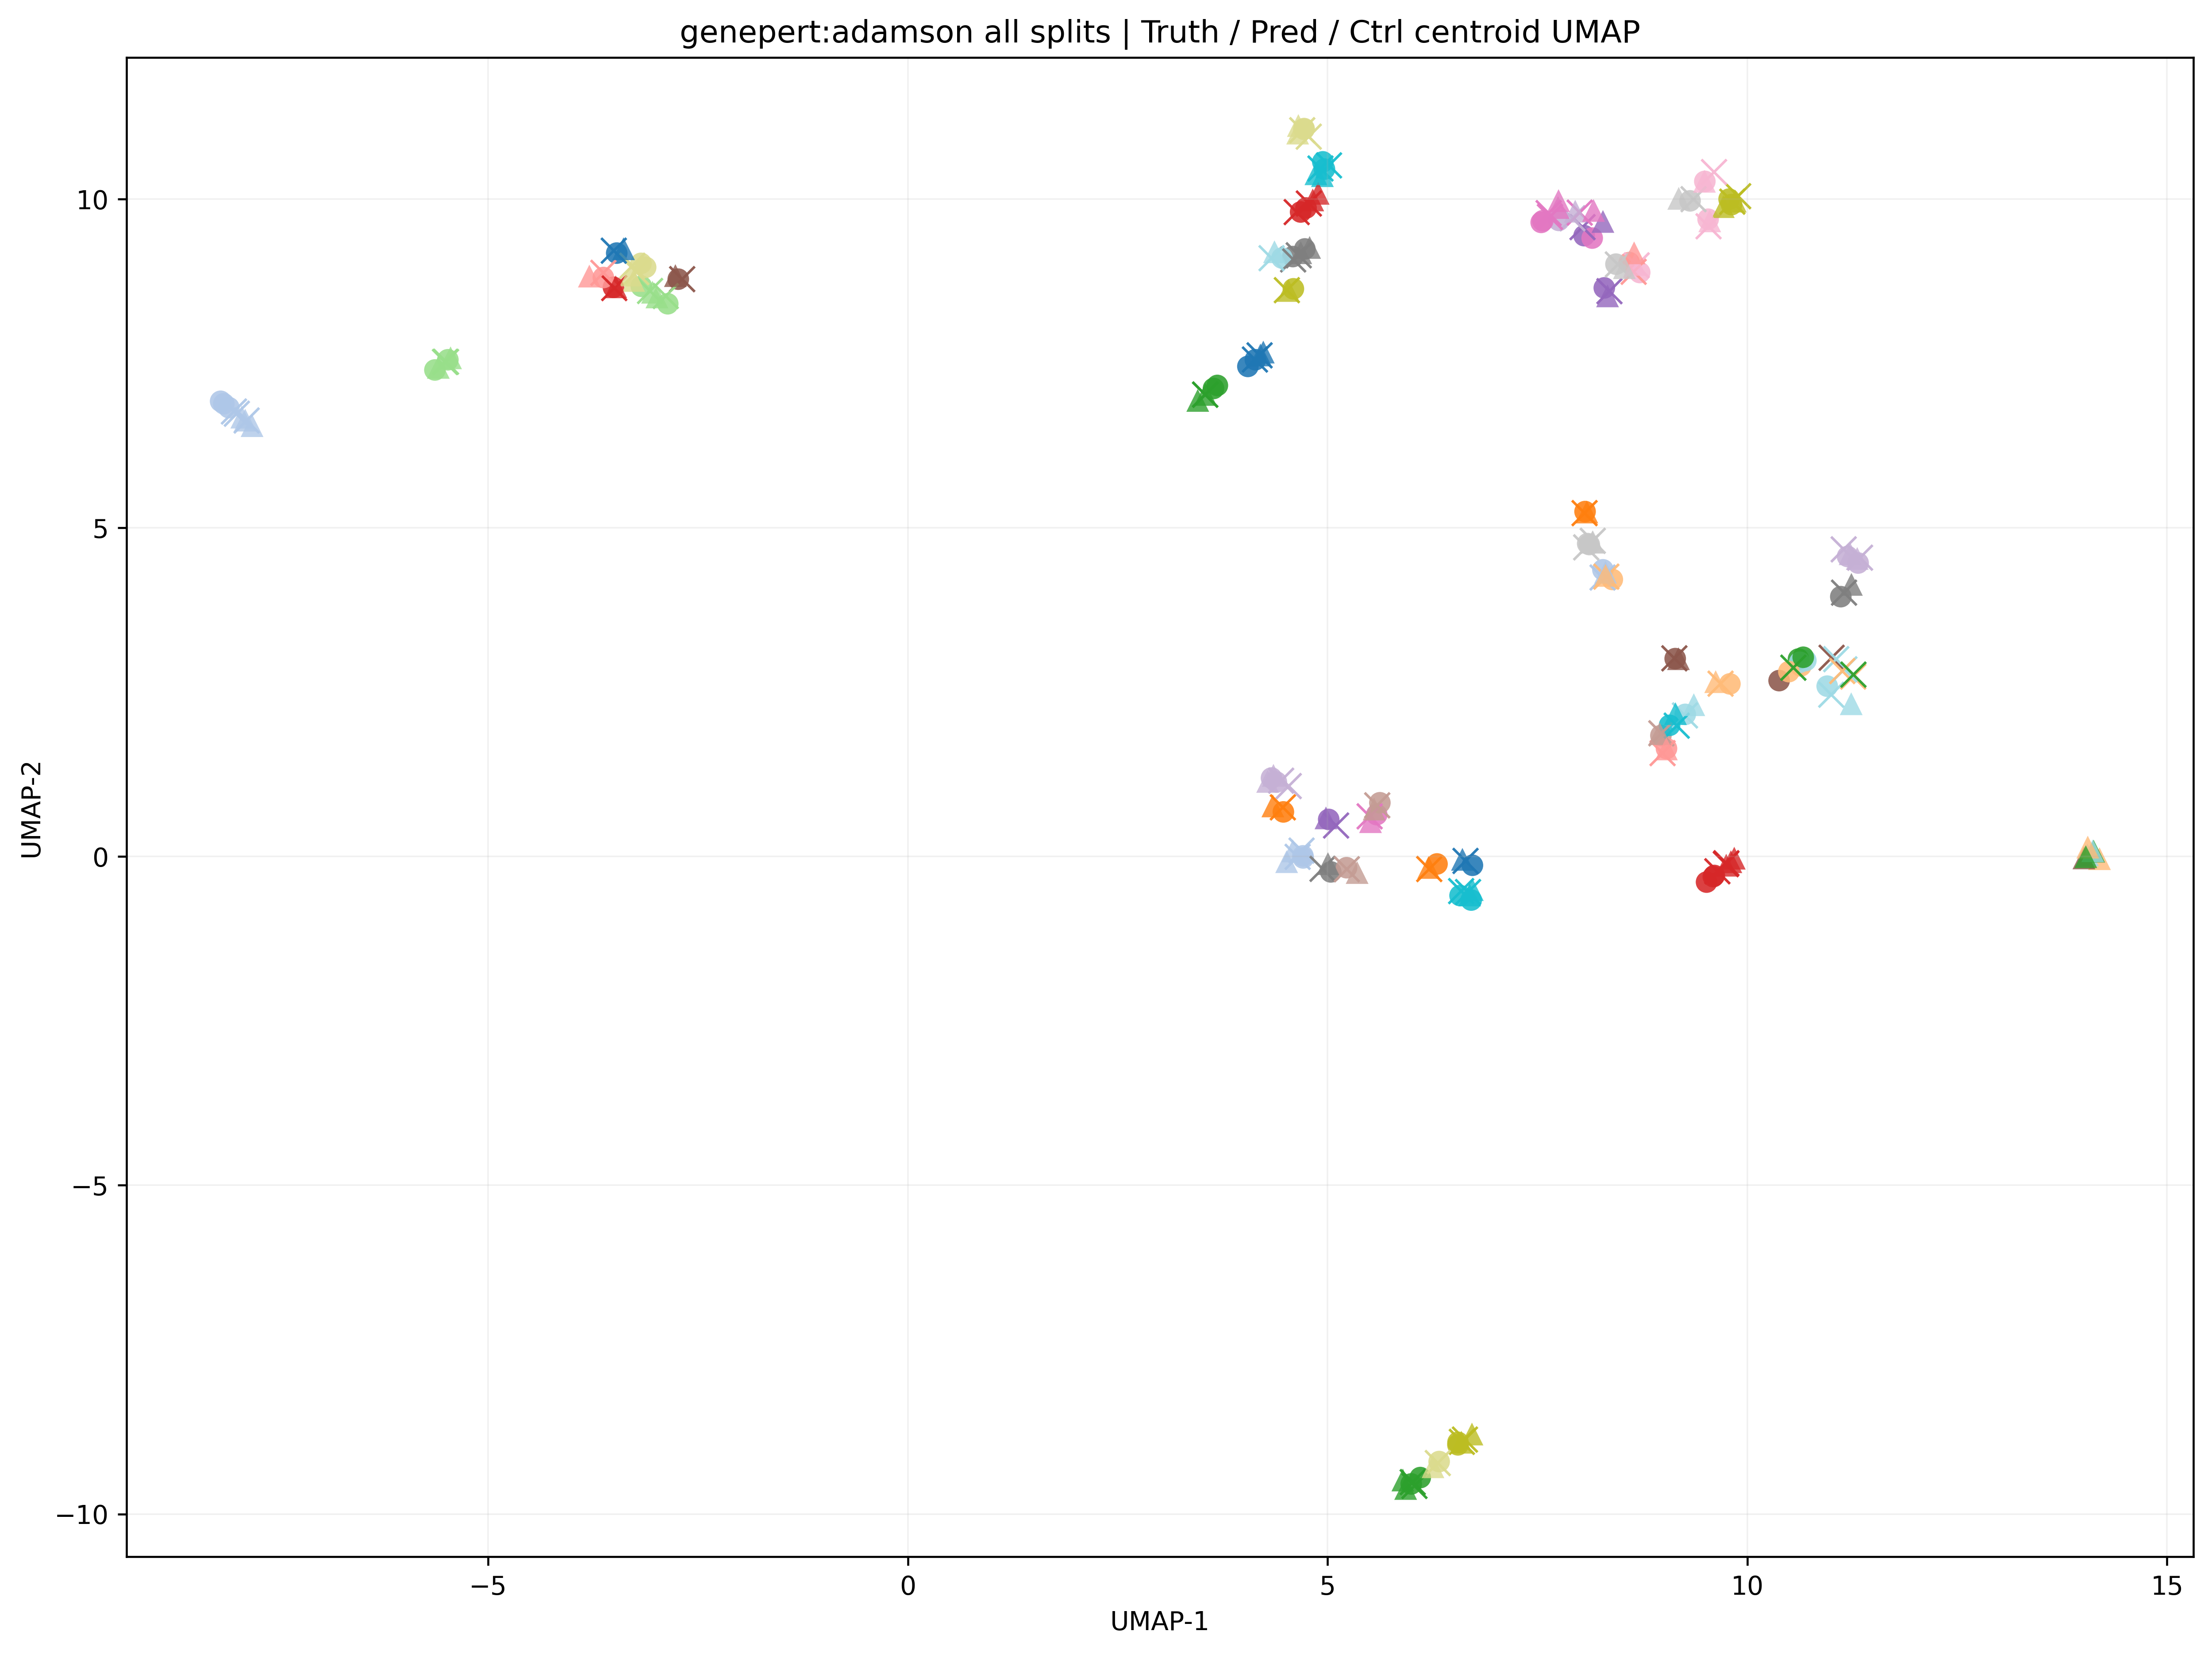

E:\CODE\trishift\notebooks\artifacts\condition_centroid_compare_adamson\trishift_truth_pred_ctrl_centroid_umap_all_splits.png


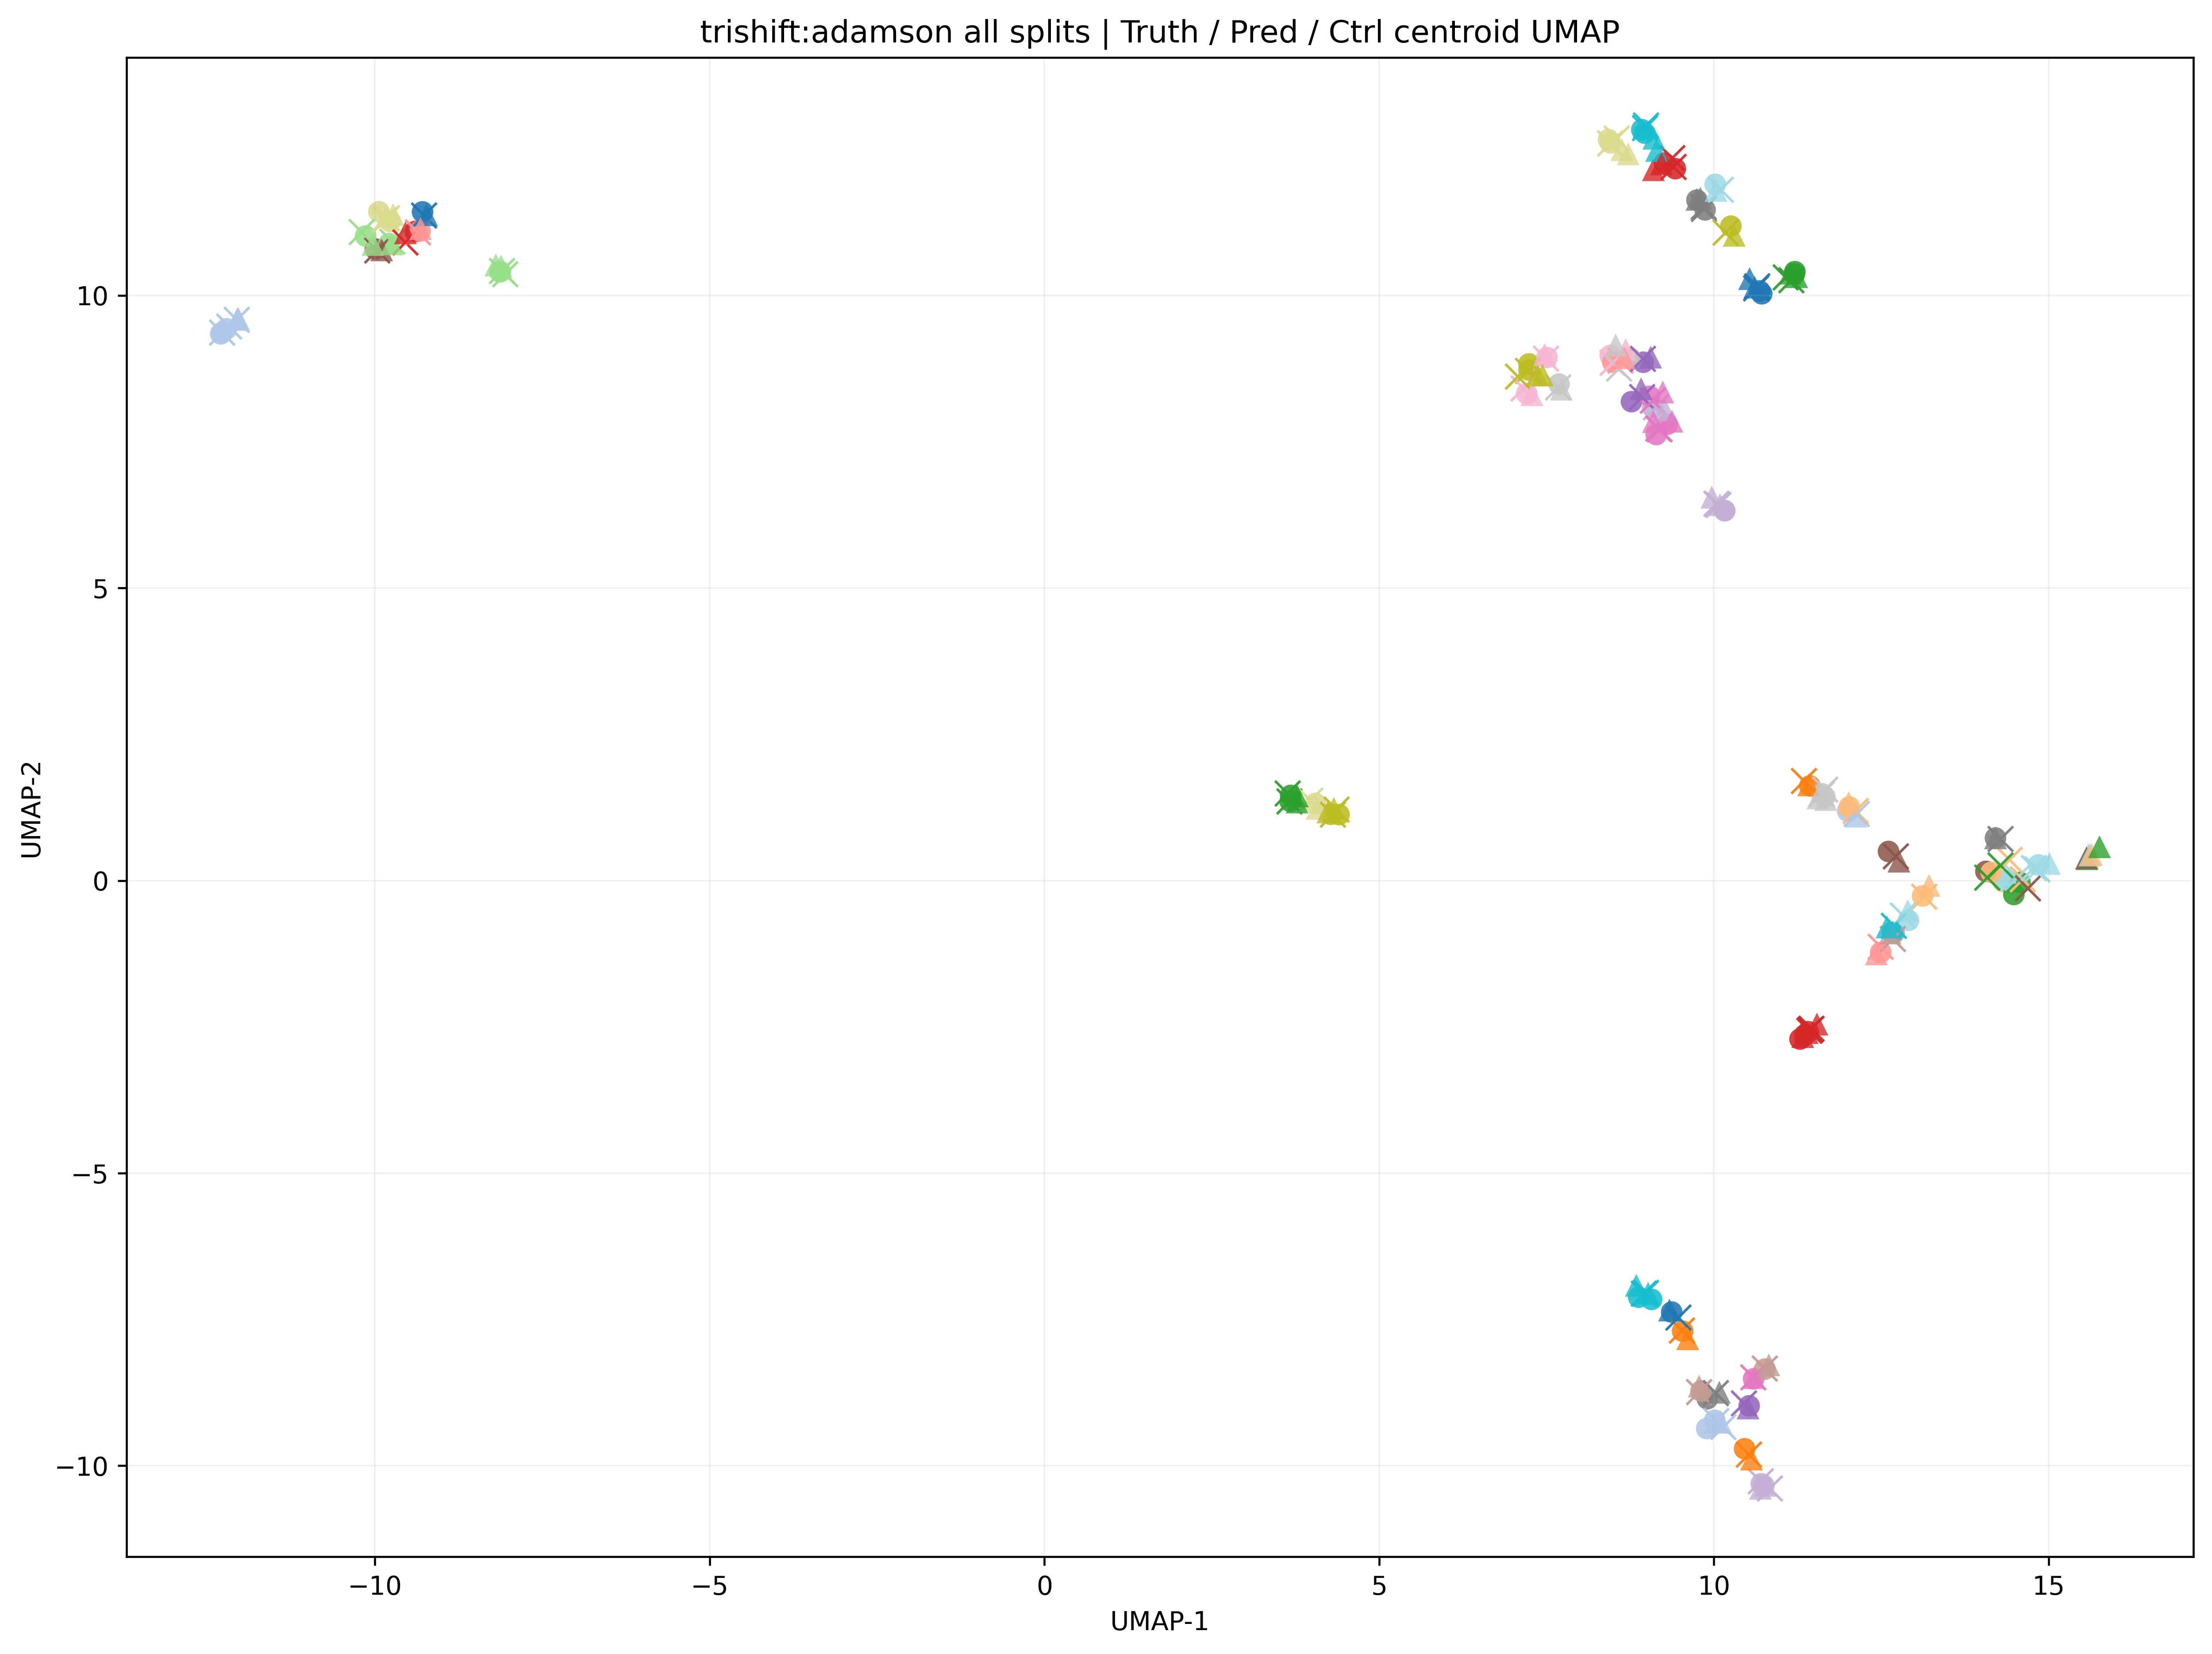

E:\CODE\trishift\notebooks\artifacts\condition_centroid_compare_adamson\gears_delta_centroid_umap_all_splits.png


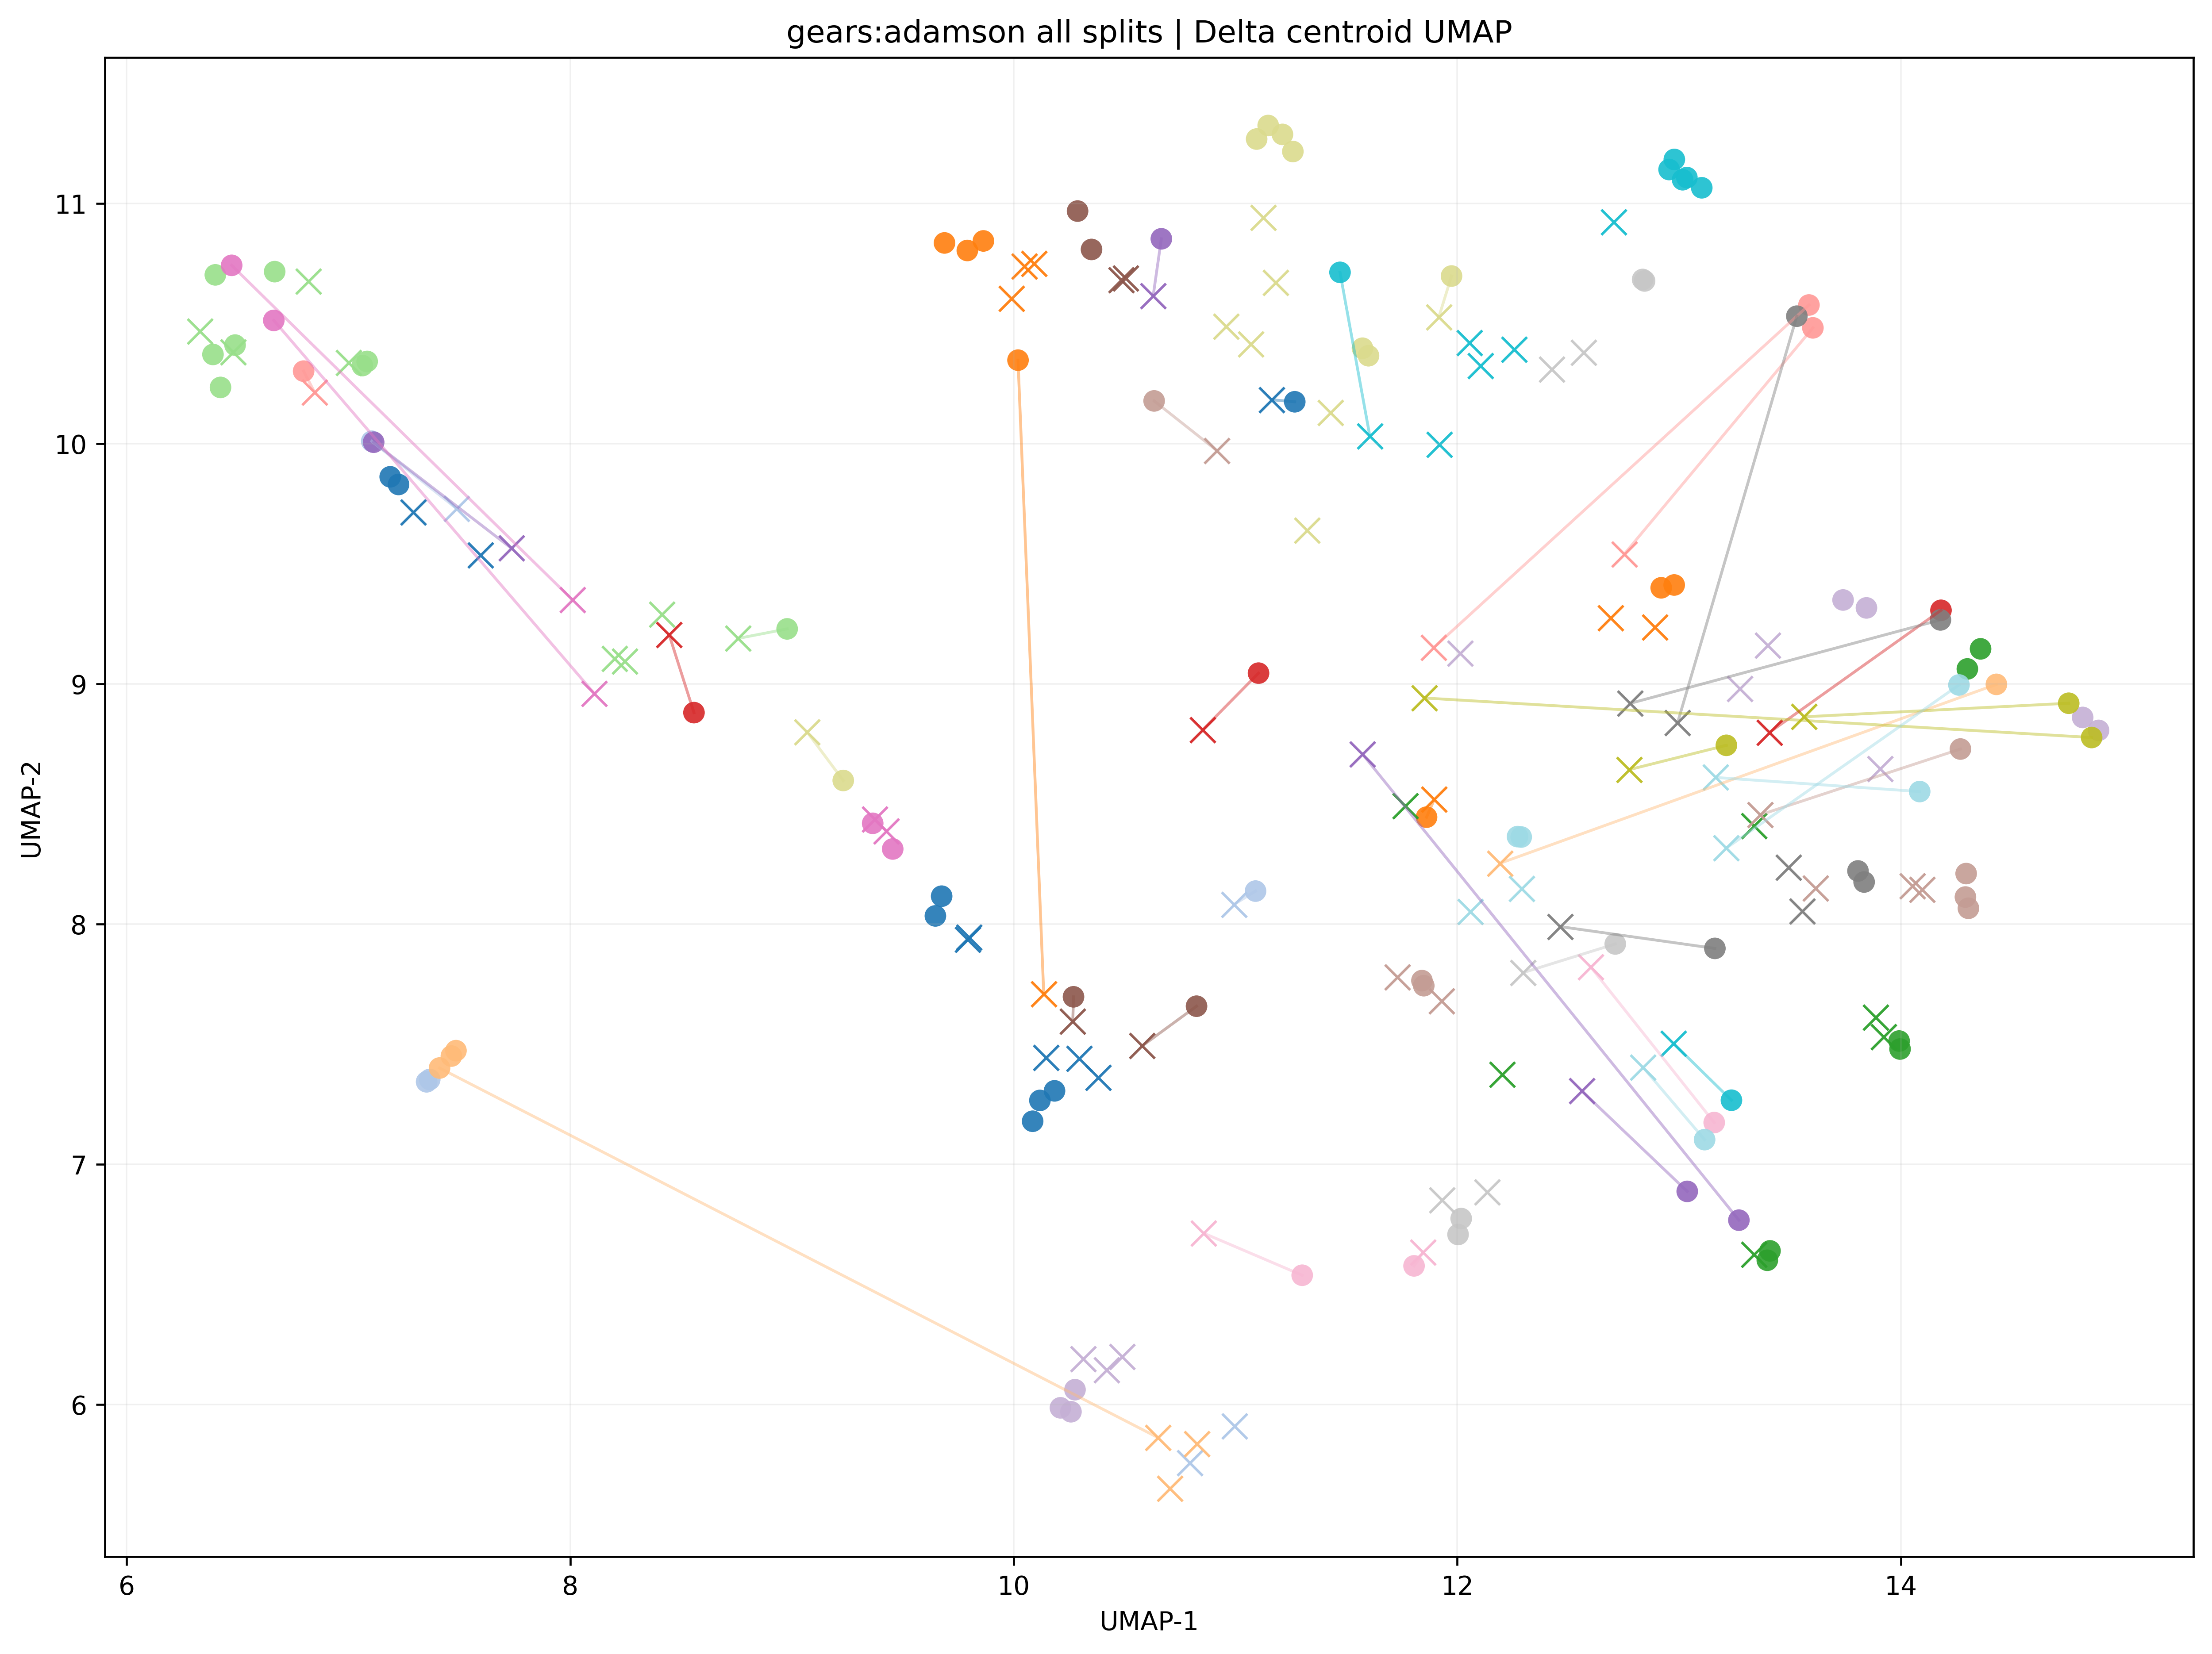

E:\CODE\trishift\notebooks\artifacts\condition_centroid_compare_adamson\genepert_delta_centroid_umap_all_splits.png


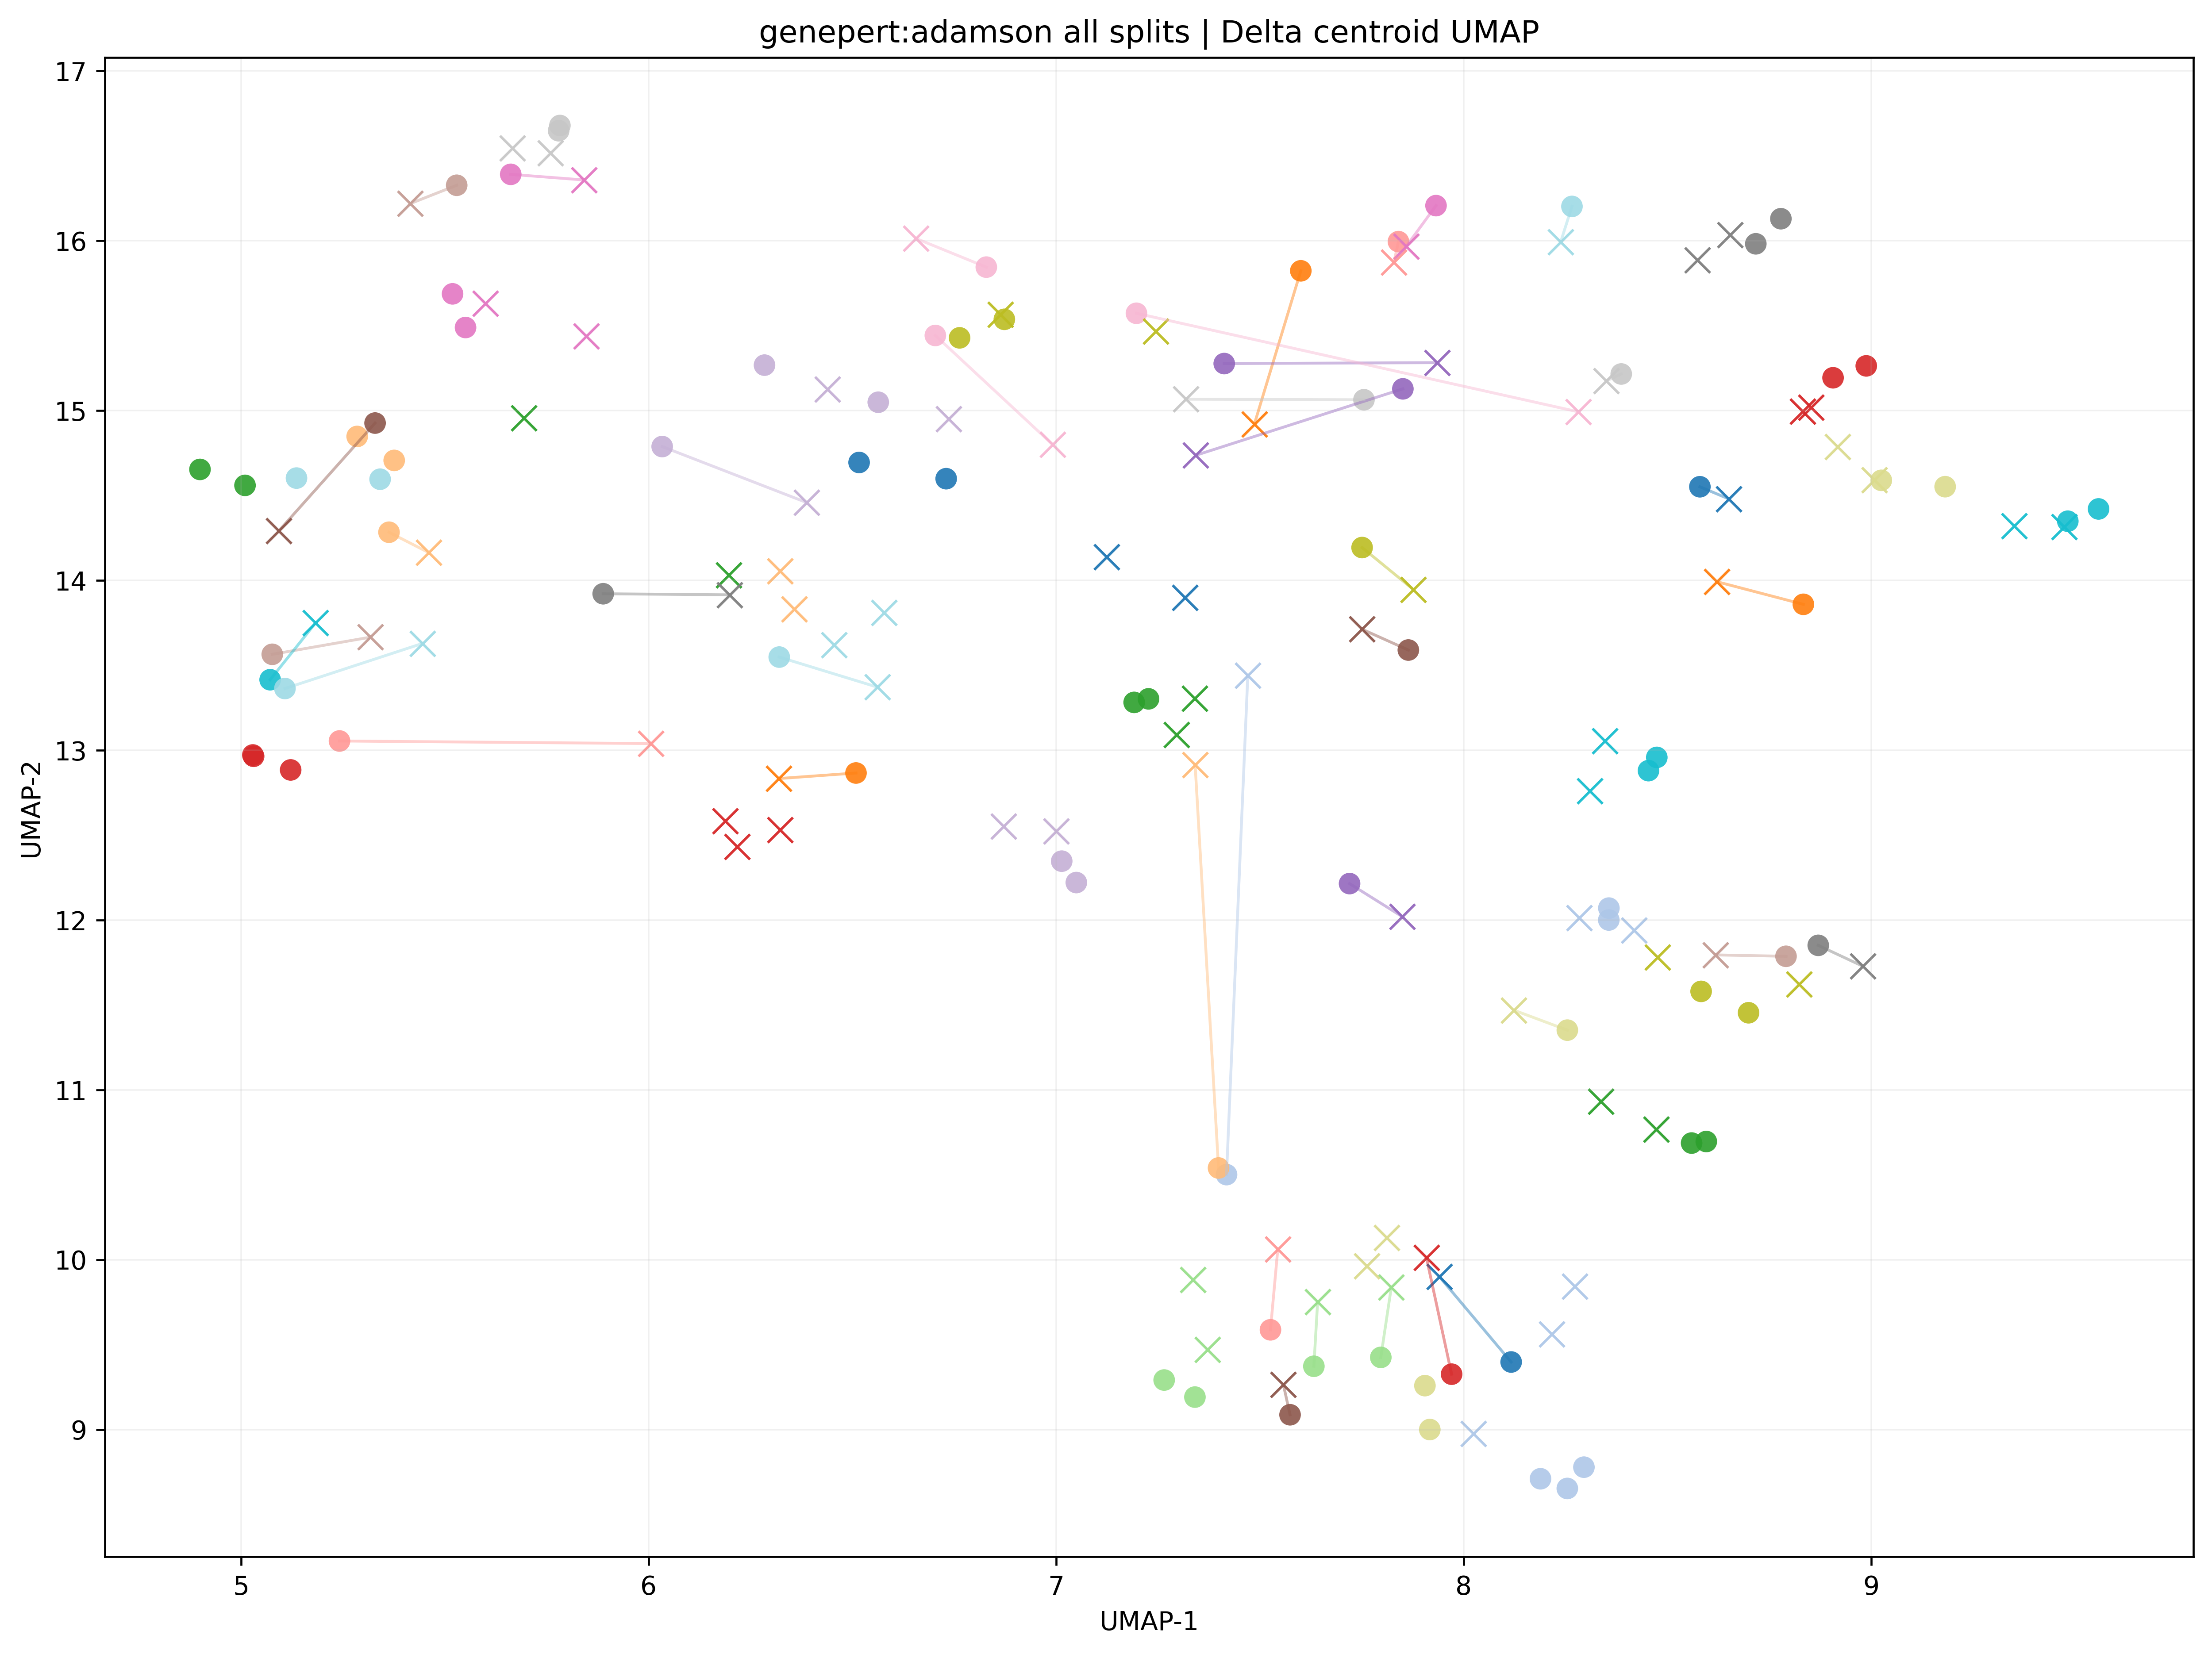

E:\CODE\trishift\notebooks\artifacts\condition_centroid_compare_adamson\trishift_delta_centroid_umap_all_splits.png


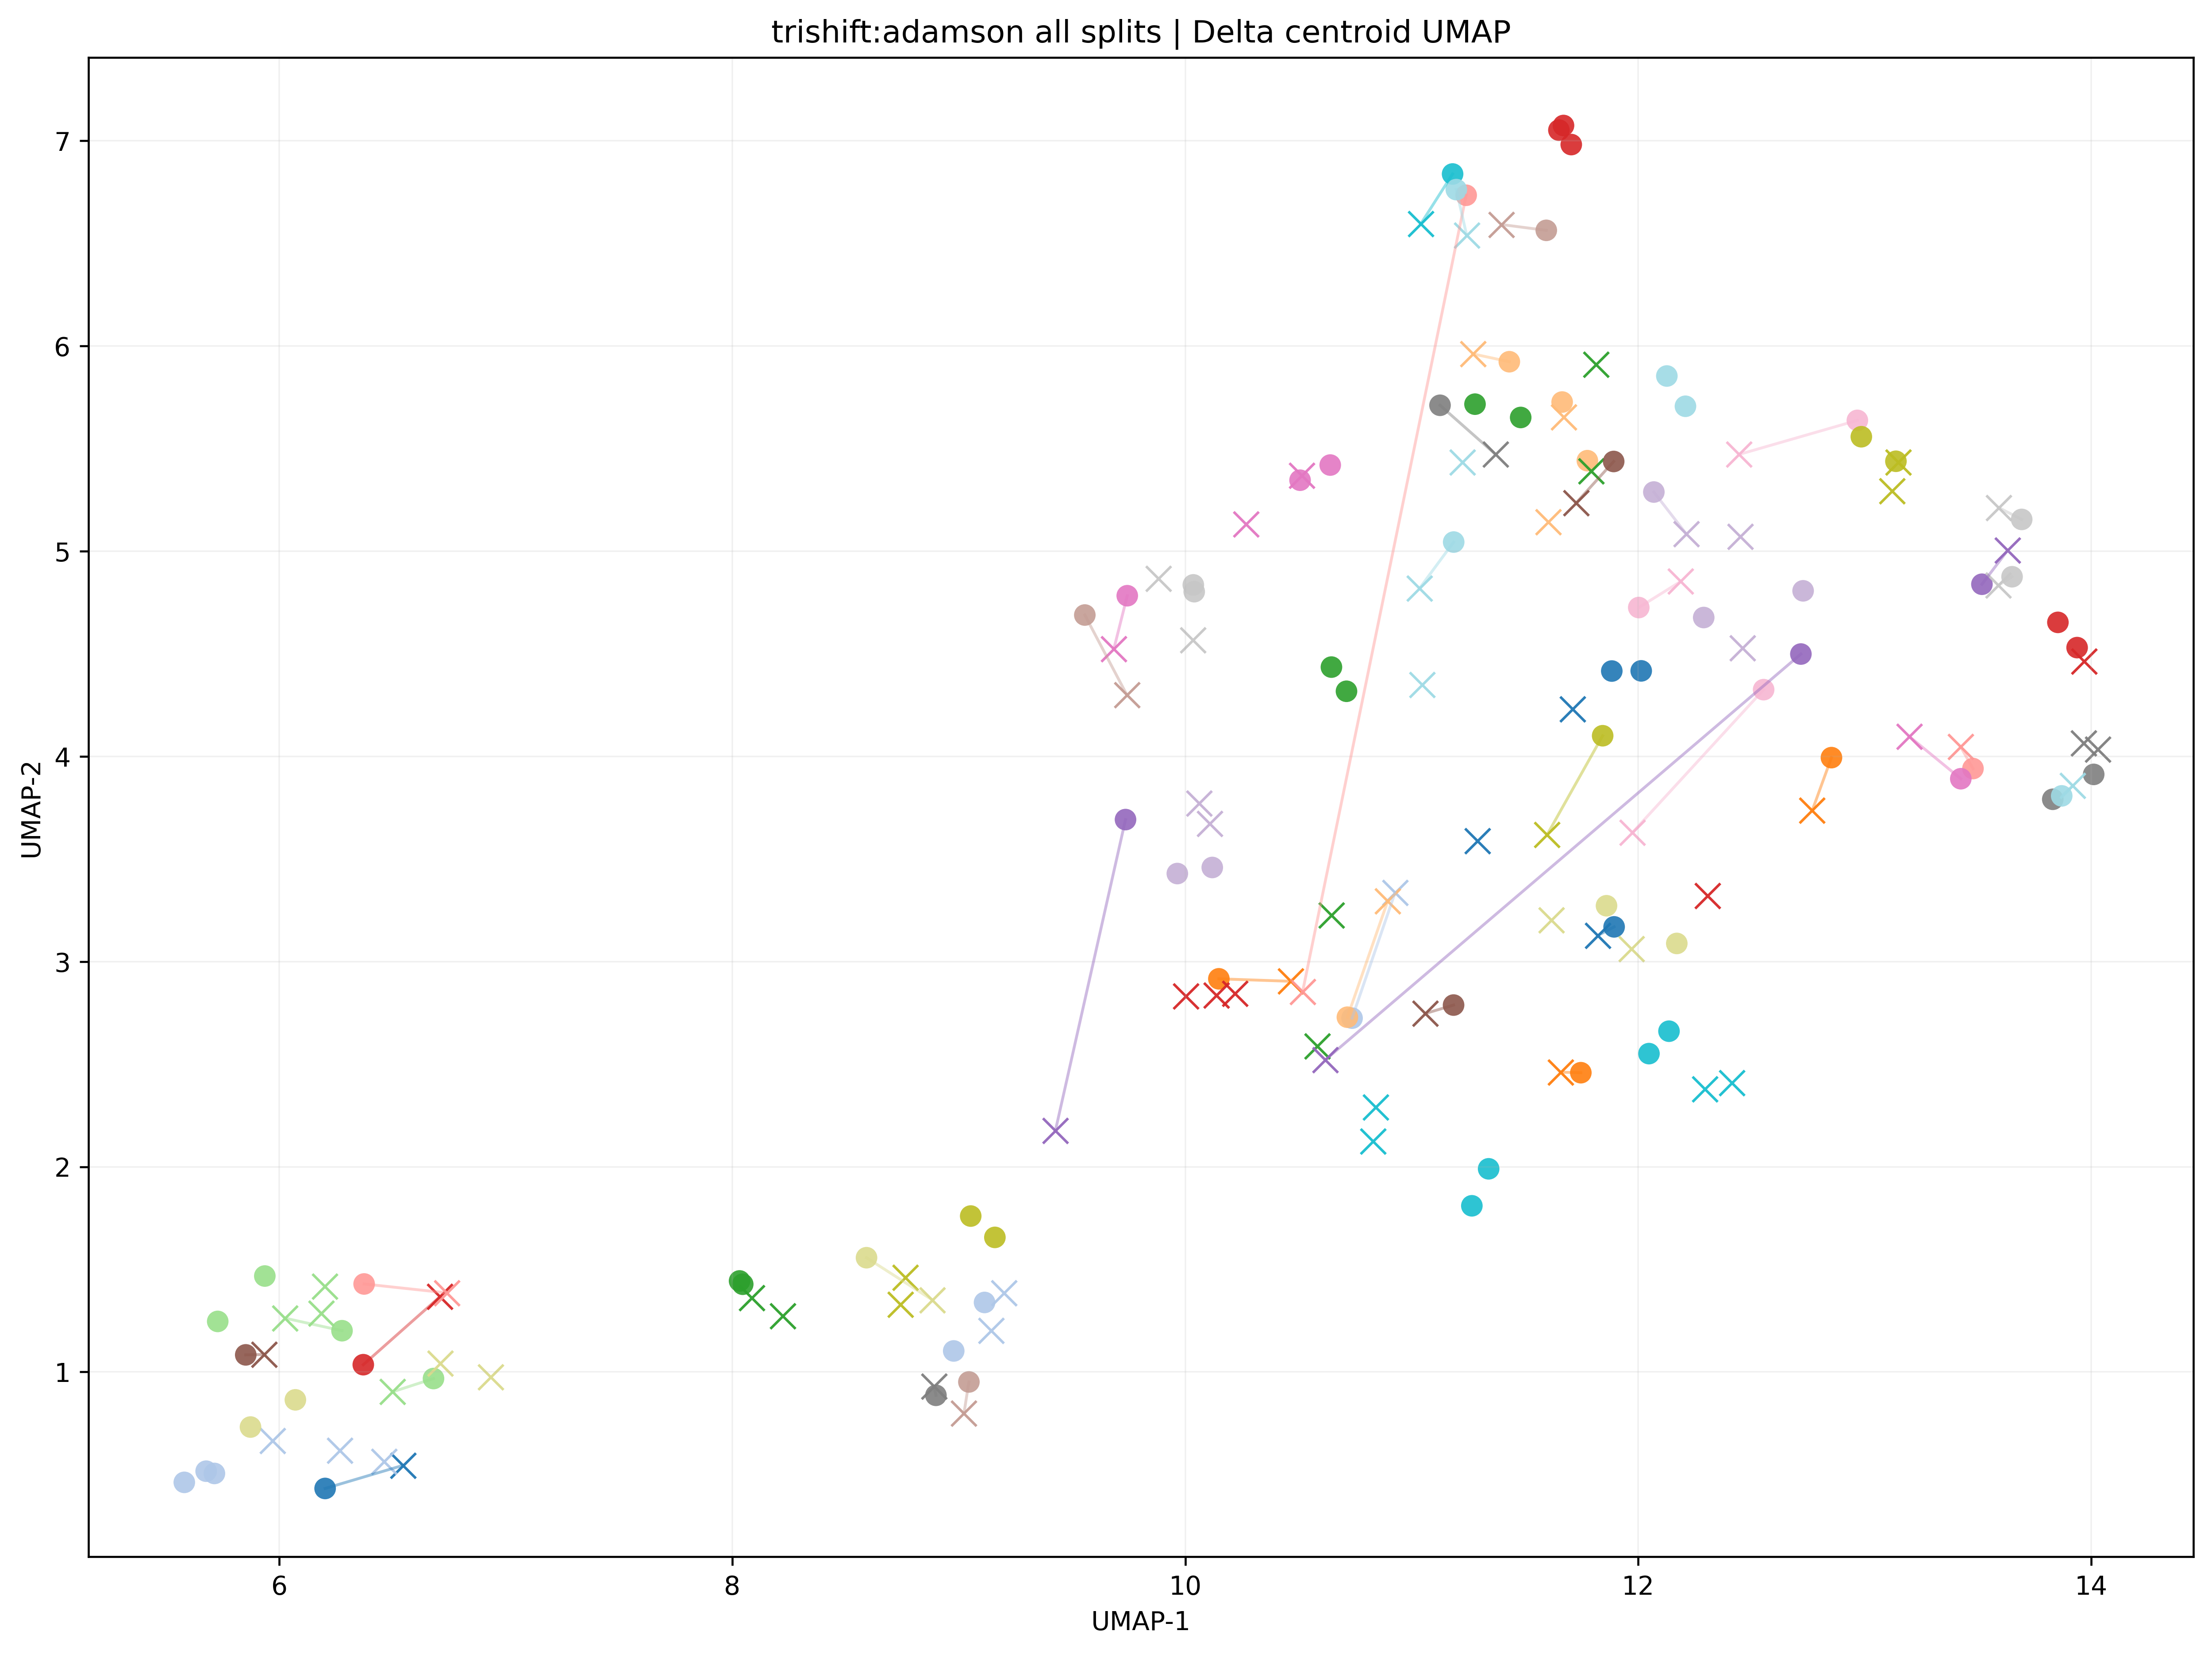

In [4]:
for path in [barplot_path, *single_main_paths, *single_delta_paths]:
    print(path)
    display(Image(filename=str(path), width=1200))


## 输出文件

这里会打印本次运行生成的 CSV、图像和元信息文件路径。


In [5]:
for path in [
    out_root / "condition_centroid_summary_all.csv",
    out_root / "condition_centroid_summary_by_model.csv",
    out_root / "condition_centroid_metrics_all.csv",
    out_root / "condition_centroid_points_all.csv",
    out_root / "condition_centroid_runs.csv",
    out_root / "condition_centroid_metric_barplot.png",
    *single_main_paths,
    *single_delta_paths,
]:
    print(path)


E:\CODE\trishift\notebooks\artifacts\condition_centroid_compare_adamson\condition_centroid_summary_all.csv
E:\CODE\trishift\notebooks\artifacts\condition_centroid_compare_adamson\condition_centroid_summary_by_model.csv
E:\CODE\trishift\notebooks\artifacts\condition_centroid_compare_adamson\condition_centroid_metrics_all.csv
E:\CODE\trishift\notebooks\artifacts\condition_centroid_compare_adamson\condition_centroid_points_all.csv
E:\CODE\trishift\notebooks\artifacts\condition_centroid_compare_adamson\condition_centroid_runs.csv
E:\CODE\trishift\notebooks\artifacts\condition_centroid_compare_adamson\condition_centroid_metric_barplot.png
E:\CODE\trishift\notebooks\artifacts\condition_centroid_compare_adamson\gears_truth_pred_ctrl_centroid_umap_all_splits.png
E:\CODE\trishift\notebooks\artifacts\condition_centroid_compare_adamson\genepert_truth_pred_ctrl_centroid_umap_all_splits.png
E:\CODE\trishift\notebooks\artifacts\condition_centroid_compare_adamson\trishift_truth_pred_ctrl_centroid_uma